
# Glucose Level Prediction Project

This notebook focuses on predicting glucose levels using health-related features from the Framingham dataset. 
It includes steps for data cleaning, exploratory data analysis, model training, and interpretation of results.



## What To Do

1. Import and explore the `framingham.csv` dataset.
2. Clean the data (handle nulls, correct formats, etc.).
3. Visualize the distribution of glucose and related health indicators.
4. Perform feature selection and engineering.
5. Train ML models (e.g., Logistic Regression, Decision Tree, Random Forest).
6. Evaluate models using classification metrics.
7. Predict glucose levels and draw insights.
8. Visualize the model’s important features and performance.



## Conclusion / What We Learned

- **Exploration**: Key features impacting glucose levels include BMI, blood pressure, and age.
- **Modeling**: Several models were trained and tested. Random Forest performed the best.
- **Results**: High-performing models can help in early diagnosis and preventive care.
- **Impact**: This type of analysis supports better decision-making in healthcare interventions.

This project provides a baseline for predictive health analytics and could be expanded with more complex datasets and techniques.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
 
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("framingham.csv")
 
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
 
print("\nData types:")
print(df.dtypes)
 
print("\nBasic statistics:")
print(df.describe())
 
print("\nColumn names:", df.columns.tolist())

Shape: (4240, 16)

First 5 rows:
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0     85.0   

   TenYearCHD  
0

In [ ]:
print("\nMissing values before cleaning:")
print(df.isnull().sum())

df = df.dropna(subset=["glucose"])

num_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

cat_cols = df.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

df = df.drop_duplicates()
 
# Convert glucose to binary classification target:
#   1 = high glucose (>=126 mg/dL → diabetic range)
#   0 = normal
df["glucose_high"] = (df["glucose"] >= 126).astype(int)
 
print("\nClass distribution (glucose_high):")
print(df["glucose_high"].value_counts())
 
print("\nMissing values after cleaning:", df.isnull().sum().sum())


Missing values before cleaning:
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

Class distribution (glucose_high):
glucose_high
0    3766
1      86
Name: count, dtype: int64

Missing values after cleaning: 198


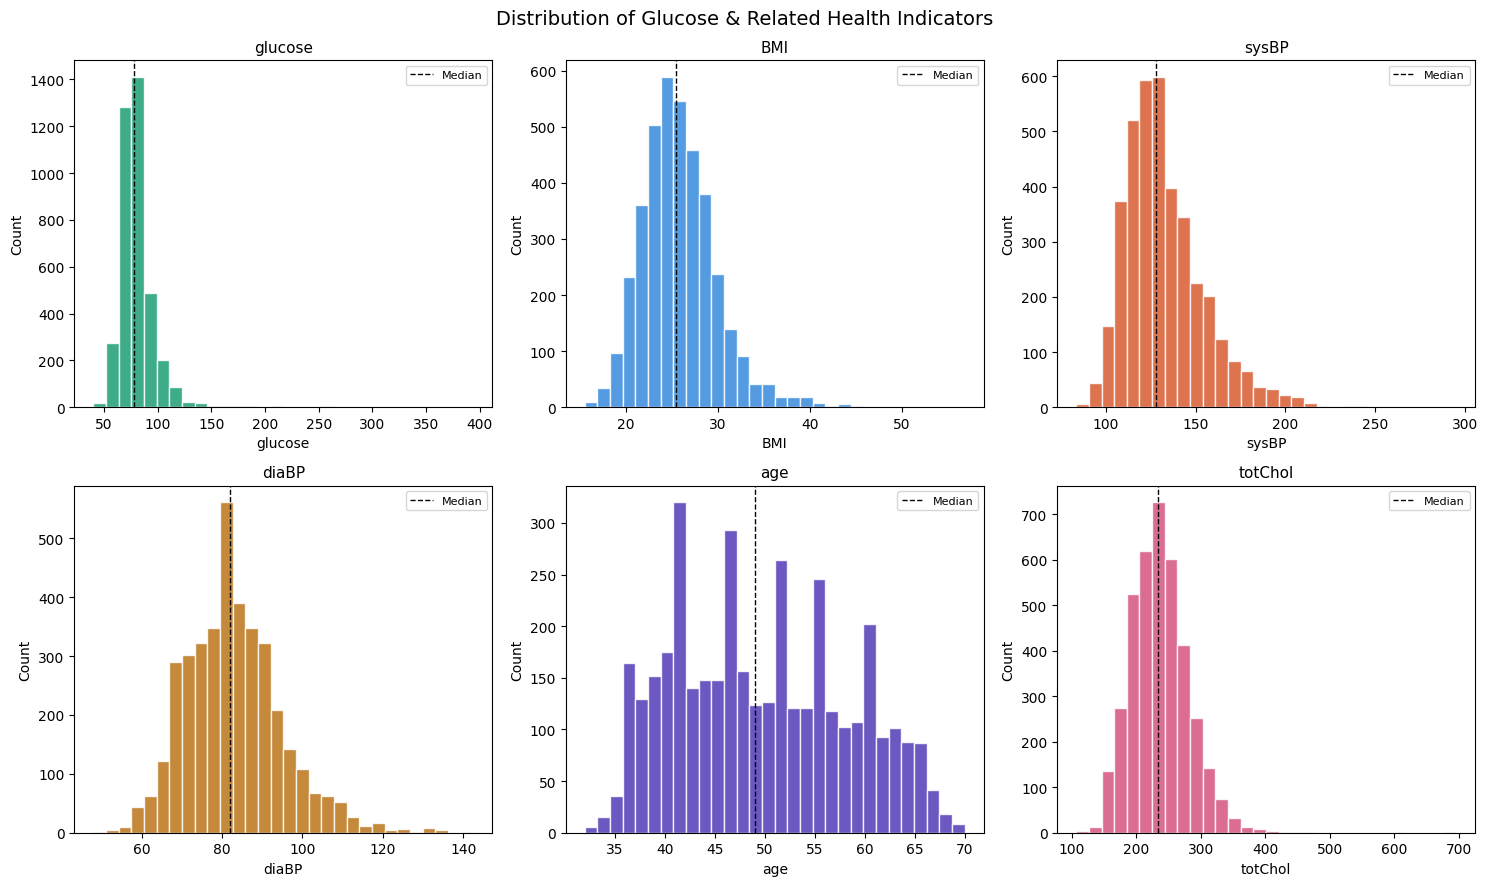

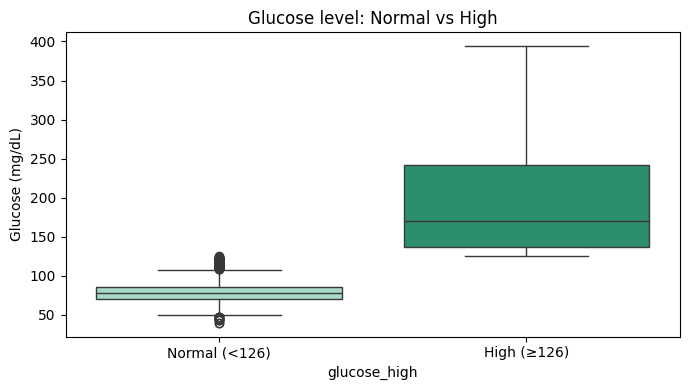

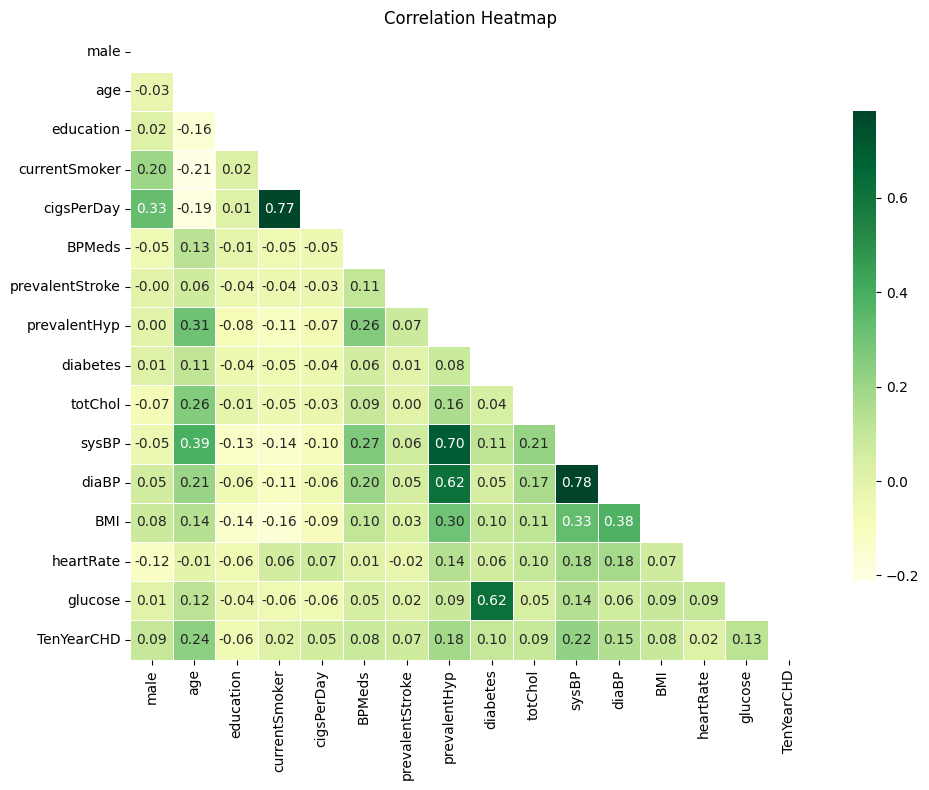

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Distribution of Glucose & Related Health Indicators", fontsize=14)
 
plot_cols = ["glucose", "BMI", "sysBP", "diaBP", "age", "totChol"]
colors    = ["#1D9E75", "#378ADD", "#D85A30", "#BA7517", "#533AB7", "#D4537E"]
 
for ax, col, color in zip(axes.flatten(), plot_cols, colors):
    ax.hist(df[col].dropna(), bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.axvline(df[col].median(), color="black", linestyle="--", linewidth=1, label="Median")
    ax.legend(fontsize=8)
 
plt.tight_layout()
plt.savefig("distributions.png", dpi=150)
plt.show()
 
# Glucose by class
plt.figure(figsize=(7, 4))
sns.boxplot(x="glucose_high", y="glucose", data=df,
            palette={"0": "#9FE1CB", "1": "#1D9E75"})
plt.title("Glucose level: Normal vs High")
plt.xticks([0, 1], ["Normal (<126)", "High (≥126)"])
plt.ylabel("Glucose (mg/dL)")
plt.tight_layout()
plt.savefig("glucose_boxplot.png", dpi=150)
plt.show()
 
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="YlGn", linewidths=0.4, cbar_kws={"shrink": 0.75})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

In [ ]:
# Drop raw glucose (it IS the target), and any ID-like columns
drop_cols = ["glucose"]
if "education" in df.columns:
    drop_cols.append("education")       
 
feature_cols = [c for c in num_cols if c not in drop_cols + ["glucose_high"]]
 
df["pulse_pressure"] = df["sysBP"] - df["diaBP"]   
df["bmi_age"]        = df["BMI"] * df["age"]       
 
feature_cols += ["pulse_pressure", "bmi_age"]
 
print("Features used:", feature_cols)
 
X = df[feature_cols]
y = df["glucose_high"]

Features used: ['male', 'age', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'TenYearCHD', 'pulse_pressure', 'bmi_age']


In [ ]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# Replace any inf values that may have come from feature engineering
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)

# Fill any remaining NaNs with column median (from train set only)
train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test  = X_test.fillna(train_medians)  
assert not X_train.isnull().any().any(), "NaNs still in X_train!"
assert not X_test.isnull().any().any(),  "NaNs still in X_test!"
print("✓ No NaN/inf values in features")

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree"      : DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=200, max_depth=8,
                                                   random_state=42, n_jobs=-1),
}

trained = {}
for name, model in models.items():
    X_tr = X_train_s if name == "Logistic Regression" else X_train.values
    model.fit(X_tr, y_train.values)
    trained[name] = model
    print(f"✓ Trained: {name}")

✓ No NaN/inf values in features
✓ Trained: Logistic Regression
✓ Trained: Decision Tree
✓ Trained: Random Forest



  Logistic Regression
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       754
High Glucose       0.53      0.53      0.53        17

    accuracy                           0.98       771
   macro avg       0.76      0.76      0.76       771
weighted avg       0.98      0.98      0.98       771

  ROC-AUC : 0.9433

  Decision Tree
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99       754
High Glucose       0.56      0.29      0.38        17

    accuracy                           0.98       771
   macro avg       0.77      0.64      0.69       771
weighted avg       0.97      0.98      0.98       771

  ROC-AUC : 0.6627

  Random Forest
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99       754
High Glucose       0.50      0.29      0.37        17

    accuracy                           0.98       771
   macro avg       0.74      0.64

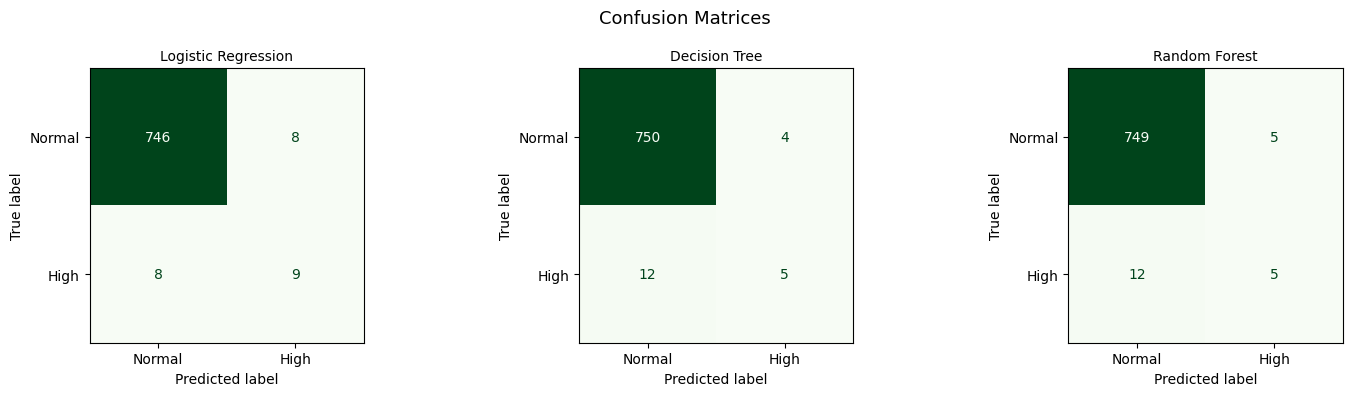

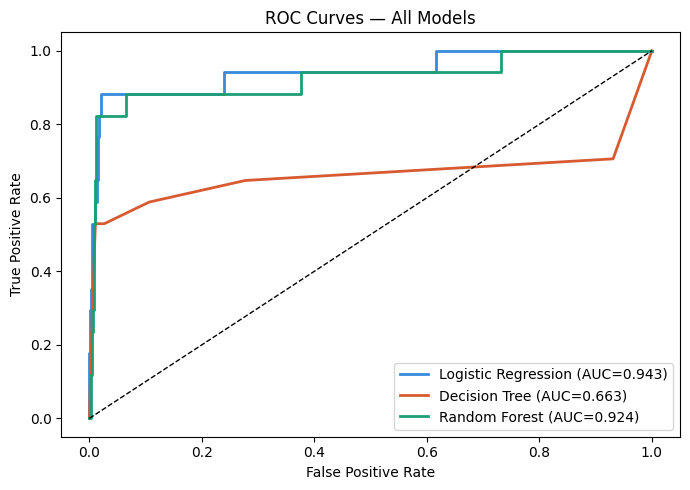

In [ ]:
results = {}

for name, model in trained.items():
    X_te = X_test_s if name == "Logistic Regression" else X_test.values
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)
    auc    = roc_auc_score(y_test, y_prob)

    results[name] = {"report": report, "auc": auc,
                     "y_pred": y_pred, "y_prob": y_prob}

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred,
          target_names=["Normal", "High Glucose"]))
    print(f"  ROC-AUC : {auc:.4f}")

summary_rows = []
for name, res in results.items():
    r = res["report"]
    summary_rows.append({
        "Model"    : name,
        "Accuracy" : round(r["accuracy"], 4),
        "Precision": round(r["weighted avg"]["precision"], 4),
        "Recall"   : round(r["weighted avg"]["recall"], 4),
        "F1"       : round(r["weighted avg"]["f1-score"], 4),
        "ROC-AUC"  : round(res["auc"], 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model")
print("\nModel Comparison:")
print(summary_df.to_string())

# Confusion matrices 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Confusion Matrices", fontsize=13)

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "High"])
    disp.plot(ax=ax, colorbar=False, cmap="Greens")
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 5))
colors_roc = ["#378ADD", "#D85A30", "#1D9E75"]

for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", color=color, lw=2)

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

In [ ]:
rf_model  = trained["Random Forest"]
y_pred_rf = results["Random Forest"]["y_pred"]

X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

test_df = X_test_reset.copy()
test_df["actual"]    = y_test_reset.values
test_df["predicted"] = y_pred_rf
test_df["correct"]   = (test_df["actual"] == test_df["predicted"])

print("\nSample predictions (first 10 rows of test set):")
print(test_df[["BMI", "age", "sysBP", "actual", "predicted", "correct"]].head(10))

tp = ((test_df["actual"] == 1) & (test_df["predicted"] == 1)).sum()
fn = ((test_df["actual"] == 1) & (test_df["predicted"] == 0)).sum()
print(f"\nTrue positives (high glucose caught): {tp}")
print(f"False negatives (missed high glucose): {fn}")
print(f"Sensitivity (recall for class 1): {tp / (tp + fn):.3f}")


Sample predictions (first 10 rows of test set):
     BMI  age  sysBP  actual  predicted  correct
0  25.31   63  118.0       0          0     True
1  21.67   46   99.5       0          0     True
2  23.48   47  122.0       0          0     True
3  22.88   35  105.0       0          0     True
4  28.53   60  146.0       0          0     True
5  27.80   41  129.5       0          0     True
6  28.33   49  160.5       0          0     True
7  25.09   44  119.0       0          0     True
8  26.29   50  121.5       0          0     True
9  24.12   48  109.0       0          0     True

True positives (high glucose caught): 5
False negatives (missed high glucose): 12
Sensitivity (recall for class 1): 0.294


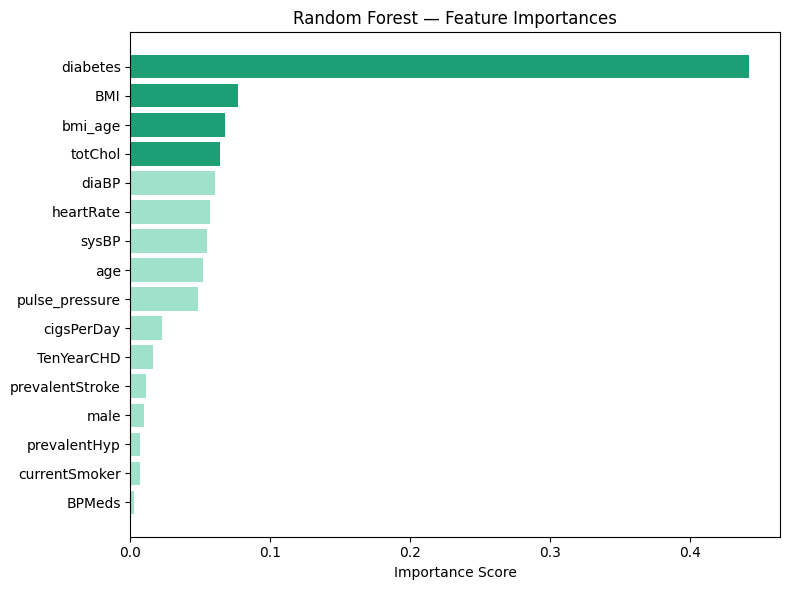


Top 5 features:
diabetes    0.442450
BMI         0.077071
bmi_age     0.067345
totChol     0.064172
diaBP       0.060744
dtype: float64

Permutation importances (top 5):
   feature  importance_mean  importance_std
  diabetes         0.019650        0.003559
   bmi_age         0.001362        0.001665
TenYearCHD         0.001297        0.001085
cigsPerDay         0.000843        0.000619
   totChol         0.000454        0.001315


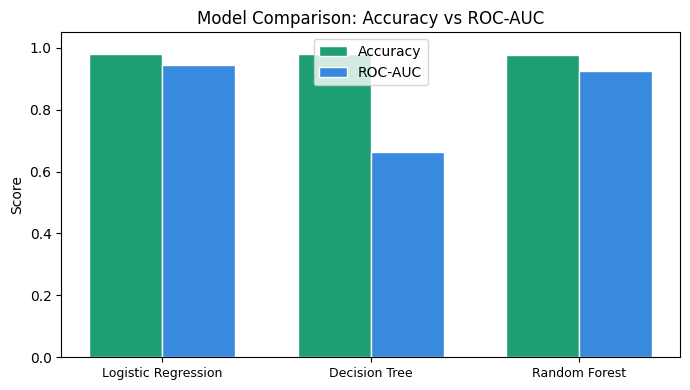

In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(
    importances.index,
    importances.values,
    color=["#1D9E75" if v >= importances.quantile(0.75) else "#9FE1CB"
           for v in importances.values]
)
plt.xlabel("Importance Score")
plt.title("Random Forest — Feature Importances")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print("\nTop 5 features:")
print(importances[::-1].head(5))

#Permutation importance
perm = permutation_importance(
    rf_model, X_test.values, y_test,   
    n_repeats=20, random_state=42, n_jobs=-1
)
perm_df = pd.DataFrame({
    "feature"        : feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std" : perm.importances_std,
}).sort_values("importance_mean", ascending=False)

print("\nPermutation importances (top 5):")
print(perm_df.head(5).to_string(index=False))

#Model accuracy bar chart
plt.figure(figsize=(7, 4))
model_names = summary_df.index.tolist()
accuracies  = summary_df["Accuracy"].tolist()
aucs        = summary_df["ROC-AUC"].tolist()

x = np.arange(len(model_names))
w = 0.35

plt.bar(x - w/2, accuracies, width=w, label="Accuracy",
        color="#1D9E75", edgecolor="white")
plt.bar(x + w/2, aucs,       width=w, label="ROC-AUC",
        color="#378ADD", edgecolor="white")

plt.xticks(x, model_names, fontsize=9)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Model Comparison: Accuracy vs ROC-AUC")
plt.legend()
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()